# RRT-Infotaxis Gas Dispersion and Sensor Models

This notebook implements the gas dispersion and sensor models from the paper:
"Receding-horizon RRT-Infotaxis for autonomous source search in urban environments"

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Set up plotting style
plt.style.use('default')
%matplotlib inline

## 2. Gaussian Dispersion Model

From Equation (1) in the paper:

$$R(r_k|\theta) = \frac{Q_0}{2\pi V \sigma_y \sigma_z} \exp\left(-\frac{c_k^2}{2\sigma_y^2}\right) \times \left[\exp\left(-\frac{(r_{z,k} - z_0)^2}{2\sigma_z^2}\right) + \exp\left(-\frac{(r_{z,k} + z_0)^2}{2\sigma_z^2}\right)\right]$$

where:
- $Q_0$ is the release rate
- $V$ is the mean wind velocity
- $\sigma_y, \sigma_z$ are standard deviations in crosswind and vertical directions
- $c_k$ is the crosswind distance
- $z_0$ is the source height

In [11]:
class GaussianPlumeModel:
    """Gaussian plume dispersion model for gas concentration."""
    
    def __init__(self, source_location, release_rate, wind_velocity, wind_direction, 
                 zeta1=20.0, zeta2=10.0, source_height=11, agent_height=11):
        """
        Initialize the Gaussian plume model.
        
        Parameters:
        -----------
        source_location : tuple (x0, y0)
            Source location in meters
        release_rate : float
            Gas release rate Q0 in g/s (will be converted to μg/s internally)
        wind_velocity : float
            Mean wind velocity V in m/s
        wind_direction : float
            Wind direction in degrees (0-360, meteorological convention: direction wind blows FROM)
        zeta1 : float
            Stochastic diffusion term in crosswind direction
        zeta2 : float
            Stochastic diffusion term in vertical direction
        source_height : float
            Height of gas source in meters
        agent_height : float
            Height of mobile agent in meters
        """
        self.x0, self.y0 = source_location
        self.Q0 = release_rate * 1e6  # Convert g/s to μg/s for realistic concentration values
        self.V = wind_velocity
        # Wind direction: meteorological convention (direction wind blows FROM)
        # Add 180° to get direction wind blows TO
        self.wind_direction = np.radians(wind_direction + 180)
        self.zeta1 = zeta1
        self.zeta2 = zeta2
        self.z0 = source_height
        self.agent_height = agent_height
    
    def compute_concentration(self, position):
        """
        Compute gas concentration at a given position.
        
        Parameters:
        -----------
        position : tuple (x, y)
            Position to compute concentration at
            
        Returns:
        --------
        concentration : float
            Mean gas concentration at the position in μg/m³
        """
        x, y = position
        
        # Transform to wind-aligned coordinate system
        dx = x - self.x0
        dy = y - self.y0
        
        # Rotate to align with wind direction
        # Downwind is positive x direction after rotation
        downwind = dx * np.cos(self.wind_direction) + dy * np.sin(self.wind_direction)
        crosswind = -dx * np.sin(self.wind_direction) + dy * np.cos(self.wind_direction)
        
        # Only compute concentration downwind of source
        if downwind <= 0.1:  # Small threshold to avoid numerical issues
            return 0.0
        
        # Compute standard deviations (Equation 2)
        sigma_y = self.zeta1 * downwind / np.sqrt(1 + 0.0001 * downwind)
        sigma_z = self.zeta2 * downwind / np.sqrt(1 + 0.0001 * downwind)
        
        # Avoid division by zero
        if sigma_y < 0.01 or sigma_z < 0.01:
            return 0.0
        
        # Compute concentration (Equation 1)
        # Crosswind term
        crosswind_term = np.exp(-crosswind**2 / (2 * sigma_y**2))
        
        # Vertical term (assuming agent at same height as source)
        z_term = (np.exp(-(self.agent_height - self.z0)**2 / (2 * sigma_z**2)) + 
                  np.exp(-(self.agent_height + self.z0)**2 / (2 * sigma_z**2)))
        
        concentration = (self.Q0 / (2 * np.pi * self.V * sigma_y * sigma_z) * 
                        crosswind_term * z_term)
        
        return concentration
    
    def compute_concentration_grid(self, x_range, y_range, resolution=1.0):
        """
        Compute concentration over a grid.
        
        Parameters:
        -----------
        x_range : tuple (xmin, xmax)
            X-axis range in meters
        y_range : tuple (ymin, ymax)
            Y-axis range in meters
        resolution : float
            Grid resolution in meters
            
        Returns:
        --------
        X, Y : ndarray
            Meshgrid coordinates
        C : ndarray
            Concentration values in μg/m³
        """
        x = np.arange(x_range[0], x_range[1], resolution)
        y = np.arange(y_range[0], y_range[1], resolution)
        X, Y = np.meshgrid(x, y)
        
        C = np.zeros_like(X)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                C[i, j] = self.compute_concentration((X[i, j], Y[i, j]))
        
        return X, Y, C

## 3. Test the Gaussian Plume Model

Let's create a simple test case and visualize the gas dispersion.

Maximum concentration: 1329868 μg/m³
Concentration at source vicinity: 4790 μg/m³
Wind blows in +X direction (to the right)


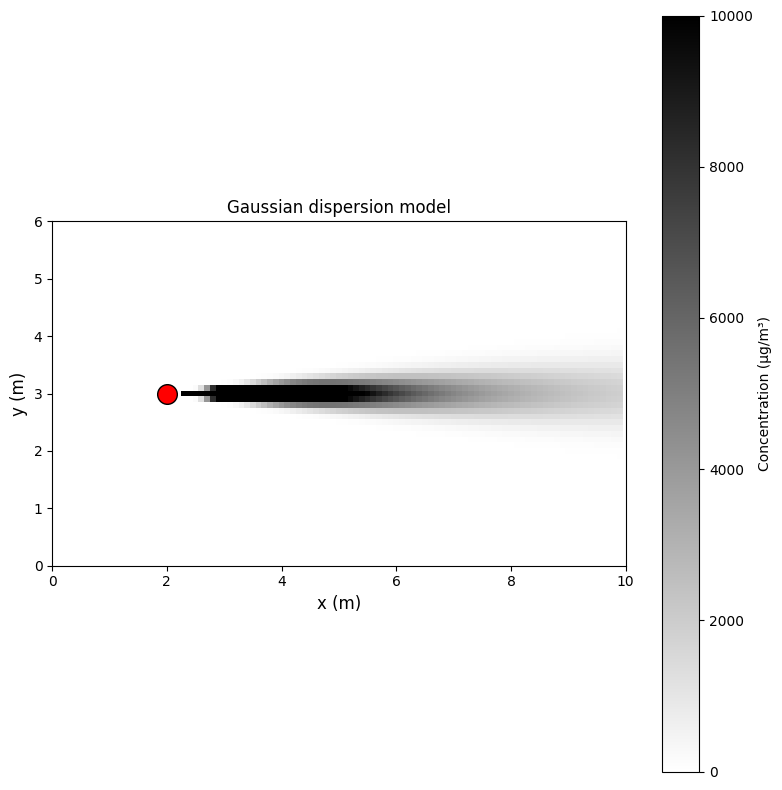

In [ ]:
# Create a simple test environment (matching paper's setup)
source_location = (2, 3)  # meters - centered for better visualization
release_rate = 0.000188  # g/s (2 kg/h as in paper)
wind_velocity = 0.1  # m/s
wind_direction = 180  # degrees (FROM 0° west, blowing TO 0° east, i.e., +X direction)

# Create model
model = GaussianPlumeModel(
    source_location=source_location,
    release_rate=release_rate,
    wind_velocity=wind_velocity,
    wind_direction=wind_direction,
    zeta1=0.05,
    zeta2=0.05
)

# Compute concentration over a grid with finer resolution
X, Y, C = model.compute_concentration_grid(
    x_range=(0, 10),
    y_range=(0, 6),
    resolution=0.1
)

# Plot the gas dispersion using pcolormesh (pixel-style like the paper)
fig, ax = plt.subplots(figsize=(8, 8))

# Use pcolormesh for pixelated appearance like in the paper
# Set concentration range similar to paper (0 to 10000 μg/m³)
vmin = 0
vmax = 10000
C_clipped = np.clip(C, vmin, vmax)

# Create pixel-style plot
im = ax.pcolormesh(X, Y, C_clipped, cmap='gray_r', vmin=vmin, vmax=vmax, shading='auto')
cbar = plt.colorbar(im, ax=ax, label='Concentration (μg/m³)')

# Mark the source
ax.scatter(*source_location, c='red', s=200, marker='o', edgecolors='black', linewidths=1, label='Source', zorder=10)

ax.set_xlabel('x (m)', fontsize=12)
ax.set_ylabel('y (m)', fontsize=12)
ax.set_title('Gaussian dispersion model', fontsize=12)
ax.set_aspect('equal')
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)

# Print statistics
print(f"Maximum concentration: {C.max():.0f} μg/m³")
print(f"Concentration at source vicinity: {model.compute_concentration((source_location[0]+5, source_location[1])):.0f} μg/m³")
print(f"Wind blows in +X direction (to the right)")

plt.tight_layout()
plt.show()

## 4. Sensor Model

From Equation (3) in the paper, the Gaussian sensor model:

$$p(z_k|\theta) = \mathcal{N}(z_k; R(r_k|\theta), \sigma_{g,k}^2)$$

where $\sigma_{g,k} = \alpha R(r_k|\theta) + \sigma_{env}$

In [5]:
class GasSensorModel:
    """Gas sensor model with Gaussian noise."""
    
    def __init__(self, alpha=1.0, sigma_env=10.0):
        """
        Initialize the sensor model.
        
        Parameters:
        -----------
        alpha : float
            Proportional noise coefficient
        sigma_env : float
            Environmental noise standard deviation
        """
        self.alpha = alpha
        self.sigma_env = sigma_env
    
    def get_measurement(self, true_concentration):
        """
        Get a noisy sensor measurement.
        
        Parameters:
        -----------
        true_concentration : float
            True gas concentration
            
        Returns:
        --------
        measurement : float
            Noisy sensor measurement
        """
        # Compute noise standard deviation (Equation 4)
        sigma_g = self.alpha * true_concentration + self.sigma_env
        
        # Generate noisy measurement
        measurement = np.random.normal(true_concentration, sigma_g)
        
        # Measurements cannot be negative
        return max(0, measurement)
    
    def likelihood(self, measurement, true_concentration):
        """
        Compute likelihood of measurement given true concentration.
        
        Parameters:
        -----------
        measurement : float
            Sensor measurement
        true_concentration : float
            True gas concentration
            
        Returns:
        --------
        likelihood : float
            p(z|theta)
        """
        sigma_g = self.alpha * true_concentration + self.sigma_env
        
        # Gaussian probability density function
        likelihood = (1.0 / (sigma_g * np.sqrt(2 * np.pi)) * 
                     np.exp(-(measurement - true_concentration)**2 / (2 * sigma_g**2)))
        
        return likelihood

## 5. Test the Sensor Model

Visualize sensor measurements with noise.

## 6. Interactive Parameter Tuning

Use the sliders below to tune zeta1 and zeta2 parameters to match the target gas dispersion pattern.

The issue is that `interact` is both creating the interactive widget AND executing the function once. Here's the fix:



In [ ]:
from ipywidgets import interact, FloatSlider, Checkbox
from PIL import Image
import matplotlib.pyplot as plt

# Load the target image
target_img = Image.open('cropped_uniform_steady_state.png')

# Set matplotlib to inline mode
%matplotlib inline

# Parameters that stay constant
source_location = (2, 3)
release_rate = 0.0000021563  # g/s
wind_velocity = 0.1 # m/s
wind_direction = 180  # Wind blows in +X direction (to the right)

# Function to create and display the plot
def plot_with_parameters(zeta1=0.05, zeta2=0.05, show_simulation=True, show_background=True):
    """
    Interactive plot that updates based on zeta1 and zeta2 slider values.
    The target image is shown with low transparency in the background.
    """
    # Create model with current parameters (always compute)
    model = GaussianPlumeModel(
        source_location=source_location,
        release_rate=release_rate,
        wind_velocity=wind_velocity,
        wind_direction=wind_direction,
        zeta1=zeta1,
        zeta2=zeta2
    )
    
    # Compute concentration grid (always compute)
    X, Y, C = model.compute_concentration_grid(
        x_range=(0, 10),
        y_range=(0, 6),
        resolution=0.1
    )
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 9))
    
    # Display target image as semi-transparent background (if enabled)
    if show_background:
        ax.imshow(target_img, extent=[0, 10, 0, 6], alpha=0.3, aspect='auto', zorder=0)
    
    # Plot the current model (always, but adjust alpha)
    vmin = 0
    vmax = 50
    C_clipped = np.clip(C, vmin, vmax)
    
    # Set alpha to 0 if show_simulation is False, otherwise 0.6
    alpha_value = 0.6 if show_simulation else 0.0
    
    im = ax.pcolormesh(X, Y, C_clipped, cmap='hot', 
                       vmin=vmin, vmax=vmax,
                       shading='auto', alpha=alpha_value, zorder=1)
    
    # Add colorbar (always show to maintain plot size)
    cbar = plt.colorbar(im, ax=ax, label='Concentration (μg/m³)')
    
    # Only show source marker if simulation is visible
    if show_simulation:
        ax.scatter(*source_location, c='cyan', s=300, marker='*', 
                   edgecolors='white', linewidths=2, label='Gas Source', zorder=10)
    
    # Add statistics box (always show)
    max_conc = C.max()
    mean_nonzero = C[C > 0].mean() if np.any(C > 0) else 0
    points_above_100 = np.sum(C > 100)
    
    stats_text = f'Max: {max_conc:.1f} μg/m³\nMean: {mean_nonzero:.1f} μg/m³\nPoints>100: {points_above_100}'
    ax.text(0.02, 0.98, stats_text, 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # Title always shows parameters
    title_text = f'Gas Concentration Tuning\nzeta1={zeta1:.3f}, zeta2={zeta2:.3f}'
    
    ax.set_xlabel('X Position (m)', fontsize=13)
    ax.set_ylabel('Y Position (m)', fontsize=13)
    ax.set_title(title_text, fontsize=15, fontweight='bold')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.set_aspect('equal')
    
    if show_simulation:
        ax.legend(loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Create interactive widget with sliders
interact(plot_with_parameters,
         zeta1=FloatSlider(min=0.01, max=5, step=0.01, value=0.33, 
                          description='zeta1:', continuous_update=False),
         zeta2=FloatSlider(min=0.01, max=5, step=0.01, value=1.58, 
                          description='zeta2:', continuous_update=False),
         show_simulation=Checkbox(value=True, description='Show Simulation'),
         show_background=Checkbox(value=True, description='Show Background'))

print("\n" + "="*60)
print("INTERACTIVE PARAMETER TUNING")
print("="*60)
print("Use the sliders above to adjust zeta1 and zeta2 parameters.")
print("- Target image is shown with LOW transparency (30%) in background")
print("- Your model output overlays with 'hot' colormap (60% opacity)")
print("- Uncheck 'Show Simulation' to hide the concentration overlay")
print("- Uncheck 'Show Background' to hide the target image")
print("- Try to match the gas dispersion pattern!")
print("="*60)

interactive(children=(FloatSlider(value=0.33, continuous_update=False, description='zeta1:', max=5.0, min=0.01…


INTERACTIVE PARAMETER TUNING
Use the sliders above to adjust zeta1 and zeta2 parameters.
- Target image is shown with LOW transparency (30%) in background
- Your model output overlays with 'hot' colormap (60% opacity)
- Uncheck 'Show Simulation' to hide the concentration overlay
- Uncheck 'Show Background' to hide the target image
- Try to match the gas dispersion pattern!


## 7. Automatic Release Rate Calibration

This cell automatically calibrates the release rate (Q0) to match target statistics from the real simulation.

In [7]:
def calibrate_release_rate(target_max, target_mean, 
                           zeta1, zeta2,
                           source_location=(2, 3), 
                           wind_velocity=0.1, 
                           wind_direction=180,
                           x_range=(0, 10), 
                           y_range=(0, 6), 
                           resolution=0.1,
                           max_iterations=20,
                           tolerance=0.05):
    """
    Automatically calibrate release rate to match target statistics.
    
    Parameters:
    -----------
    target_max : float
        Target maximum concentration (μg/m³)
    target_mean : float
        Target mean concentration (μg/m³) - for non-zero values
    zeta1, zeta2 : float
        Diffusion parameters (should be already tuned for shape)
    source_location, wind_velocity, wind_direction : various
        Other model parameters
    x_range, y_range : tuple
        Grid ranges
    resolution : float
        Grid resolution
    max_iterations : int
        Maximum calibration iterations
    tolerance : float
        Relative error tolerance (e.g., 0.05 = 5%)
        
    Returns:
    --------
    calibrated_release_rate : float
        Calibrated release rate in g/s
    final_stats : dict
        Final statistics from the calibrated model
    """
    
    print("="*70)
    print("AUTOMATIC RELEASE RATE CALIBRATION (PRIORITIZING MEAN)")
    print("="*70)
    print(f"Target statistics:")
    print(f"  Max concentration: {target_max:.2f} μg/m³")
    print(f"  Mean concentration: {target_mean:.2f} μg/m³")
    print(f"\nCalibration parameters:")
    print(f"  zeta1 = {zeta1:.3f}, zeta2 = {zeta2:.3f}")
    print(f"  Max iterations: {max_iterations}")
    print(f"  Tolerance: {tolerance*100:.1f}%")
    print("-"*70)
    
    # Initial guess - use mean concentration as primary calibration target
    # Start with a small value
    release_rate = 0.00001  # g/s
    
    for iteration in range(max_iterations):
        # Create model with current release rate
        model = GaussianPlumeModel(
            source_location=source_location,
            release_rate=release_rate,
            wind_velocity=wind_velocity,
            wind_direction=wind_direction,
            zeta1=zeta1,
            zeta2=zeta2
        )
        
        # Compute concentration grid
        X, Y, C = model.compute_concentration_grid(
            x_range=x_range,
            y_range=y_range,
            resolution=resolution
        )
        
        # Calculate current statistics
        current_max = C.max()
        current_mean = C[C > 0].mean() if np.any(C > 0) else 0
        
        # Calculate relative errors
        error_max = abs(current_max - target_max) / target_max
        error_mean = abs(current_mean - target_mean) / target_mean if target_mean > 0 else 0
        
        print(f"Iteration {iteration+1:2d}: Q0 = {release_rate:.8f} g/s")
        print(f"              Current: Max = {current_max:6.2f} μg/m³, Mean = {current_mean:6.3f} μg/m³")
        print(f"              Errors:  Max = {error_max*100:5.1f}%, Mean = {error_mean*100:5.1f}%")
        
        # Check convergence (prioritize MEAN concentration)
        if error_mean < tolerance:
            print("-"*70)
            print(f"✓ CONVERGED after {iteration+1} iterations!")
            print(f"  Final Mean error: {error_mean*100:.2f}%")
            print(f"  Final Max error: {error_max*100:.2f}%")
            print("="*70)
            
            return release_rate, {
                'max': current_max,
                'mean': current_mean,
                'target_max': target_max,
                'target_mean': target_mean,
                'error_max': error_max,
                'error_mean': error_mean,
                'iterations': iteration + 1
            }
        
        # Adjust release rate based on MEAN concentration error
        # Use simple proportional adjustment
        scaling_factor = target_mean / current_mean
        release_rate *= scaling_factor
        
        print()
    
    # Max iterations reached
    print("-"*70)
    print(f"⚠ Maximum iterations ({max_iterations}) reached.")
    print(f"  Best Mean error: {error_mean*100:.2f}%")
    print(f"  Best Max error: {error_max*100:.2f}%")
    print("  Consider increasing max_iterations or tolerance.")
    print("="*70)
    
    return release_rate, {
        'max': current_max,
        'mean': current_mean,
        'target_max': target_max,
        'target_mean': target_mean,
        'error_max': error_max,
        'error_mean': error_mean,
        'iterations': max_iterations
    }


# Run calibration with your target values
TARGET_MAX = 43.1  # μg/m³ from real simulation
TARGET_MEAN = 0.884  # μg/m³ from real simulation

# Use your tuned zeta values
ZETA1 = 0.33
ZETA2 = 1.58

# Run calibration
calibrated_Q0, stats = calibrate_release_rate(
    target_max=TARGET_MAX,
    target_mean=TARGET_MEAN,
    zeta1=ZETA1,
    zeta2=ZETA2,
    tolerance=0.01  # 1% tolerance
)

print(f"\n{'='*70}")
print(f"CALIBRATION RESULT")
print(f"{'='*70}")
print(f"Calibrated release rate: {calibrated_Q0:.10f} g/s")
print(f"                       = {calibrated_Q0*1e6:.4f} μg/s")
print(f"\nUse this value in your model:")
print(f"  release_rate = {calibrated_Q0:.10f}  # g/s (calibrated)")
print(f"{'='*70}")

AUTOMATIC RELEASE RATE CALIBRATION (PRIORITIZING MEAN)
Target statistics:
  Max concentration: 43.10 μg/m³
  Mean concentration: 0.88 μg/m³

Calibration parameters:
  zeta1 = 0.330, zeta2 = 1.580
  Max iterations: 20
  Tolerance: 1.0%
----------------------------------------------------------------------
Iteration  1: Q0 = 0.00001000 g/s
              Current: Max = 3052.48 μg/m³, Mean =  4.100 μg/m³
              Errors:  Max = 6982.3%, Mean = 363.8%

Iteration  2: Q0 = 0.00000216 g/s
              Current: Max = 658.20 μg/m³, Mean =  0.884 μg/m³
              Errors:  Max = 1427.1%, Mean =   0.0%
----------------------------------------------------------------------
✓ CONVERGED after 2 iterations!
  Final Mean error: 0.00%
  Final Max error: 1427.14%

CALIBRATION RESULT
Calibrated release rate: 0.0000021563 g/s
                       = 2.1563 μg/s

Use this value in your model:
  release_rate = 0.0000021563  # g/s (calibrated)


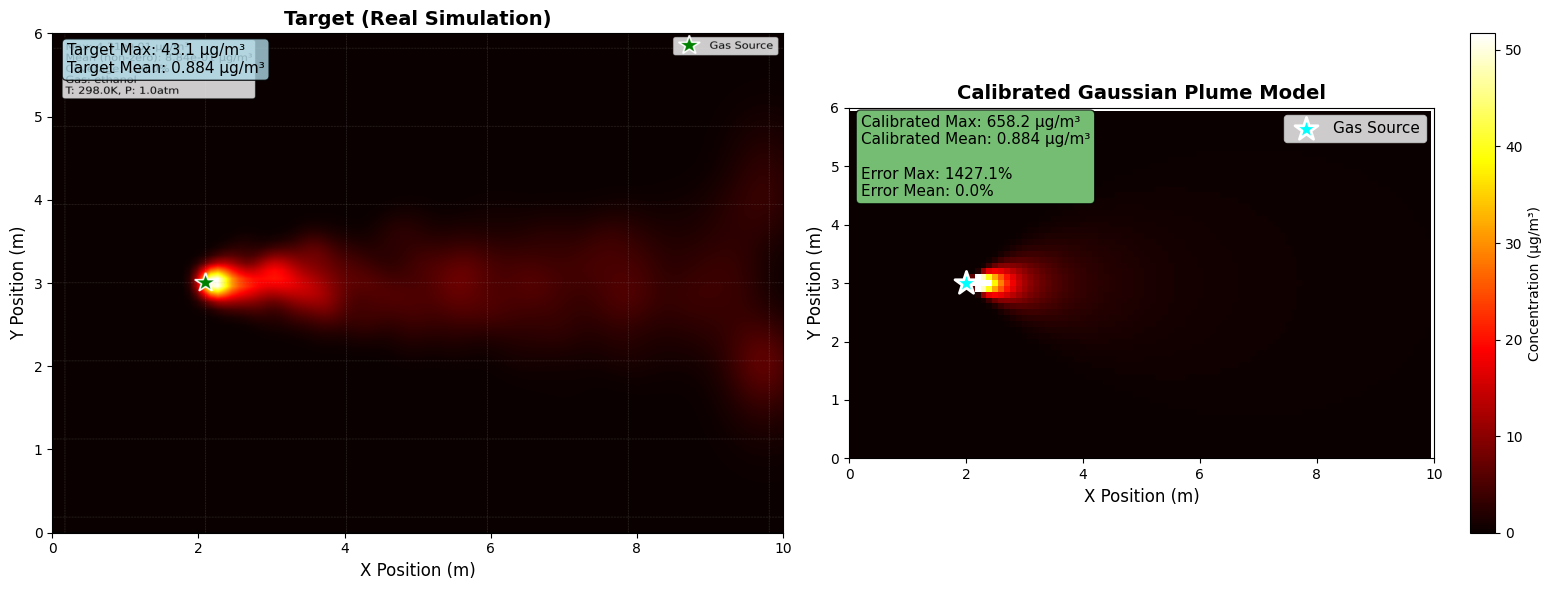


CALIBRATION SUMMARY
Model Parameters:
  Source location: (2, 3) m
  Wind velocity: 0.1 m/s
  Wind direction: 180° (blowing East, +X direction)
  zeta1 (crosswind): 0.330
  zeta2 (vertical): 1.580
  Release rate Q0: 0.0000021563 g/s

Statistics:
  Target:     Max = 43.10 μg/m³, Mean = 0.884 μg/m³
  Calibrated: Max = 658.20 μg/m³, Mean = 0.884 μg/m³
  Errors:     Max = 1427.14%, Mean = 0.00%


In [8]:
# Visualize the calibrated model alongside the target
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Create calibrated model
calibrated_model = GaussianPlumeModel(
    source_location=(2, 3),
    release_rate=calibrated_Q0,
    wind_velocity=0.1,
    wind_direction=180,
    zeta1=ZETA1,
    zeta2=ZETA2
)

# Compute concentration grid
X, Y, C_calibrated = calibrated_model.compute_concentration_grid(
    x_range=(0, 10),
    y_range=(0, 6),
    resolution=0.1
)

# Plot 1: Target image
axes[0].imshow(target_img, extent=[0, 10, 0, 6], aspect='auto')
axes[0].set_title('Target (Real Simulation)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('X Position (m)', fontsize=12)
axes[0].set_ylabel('Y Position (m)', fontsize=12)
axes[0].text(0.02, 0.98, f'Target Max: {TARGET_MAX:.1f} μg/m³\nTarget Mean: {TARGET_MEAN:.3f} μg/m³',
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Plot 2: Calibrated model
vmax = max(50, TARGET_MAX * 1.2)  # Set reasonable max for colormap
im = axes[1].pcolormesh(X, Y, C_calibrated, cmap='hot', vmin=0, vmax=vmax, shading='auto')
cbar = plt.colorbar(im, ax=axes[1], label='Concentration (μg/m³)')
axes[1].scatter(2, 3, c='cyan', s=300, marker='*', edgecolors='white', linewidths=2, label='Gas Source', zorder=10)
axes[1].set_title('Calibrated Gaussian Plume Model', fontsize=14, fontweight='bold')
axes[1].set_xlabel('X Position (m)', fontsize=12)
axes[1].set_ylabel('Y Position (m)', fontsize=12)
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 6)
axes[1].set_aspect('equal')
axes[1].legend(loc='upper right', fontsize=11)

# Add statistics
cal_max = C_calibrated.max()
cal_mean = C_calibrated[C_calibrated > 0].mean()
axes[1].text(0.02, 0.98, 
             f'Calibrated Max: {cal_max:.1f} μg/m³\nCalibrated Mean: {cal_mean:.3f} μg/m³\n\n'
             f'Error Max: {abs(cal_max-TARGET_MAX)/TARGET_MAX*100:.1f}%\n'
             f'Error Mean: {abs(cal_mean-TARGET_MEAN)/TARGET_MEAN*100:.1f}%',
             transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CALIBRATION SUMMARY")
print("="*70)
print(f"Model Parameters:")
print(f"  Source location: (2, 3) m")
print(f"  Wind velocity: 0.1 m/s")
print(f"  Wind direction: 180° (blowing East, +X direction)")
print(f"  zeta1 (crosswind): {ZETA1:.3f}")
print(f"  zeta2 (vertical): {ZETA2:.3f}")
print(f"  Release rate Q0: {calibrated_Q0:.10f} g/s")
print(f"\nStatistics:")
print(f"  Target:     Max = {TARGET_MAX:.2f} μg/m³, Mean = {TARGET_MEAN:.3f} μg/m³")
print(f"  Calibrated: Max = {cal_max:.2f} μg/m³, Mean = {cal_mean:.3f} μg/m³")
print(f"  Errors:     Max = {abs(cal_max-TARGET_MAX)/TARGET_MAX*100:.2f}%, Mean = {abs(cal_mean-TARGET_MEAN)/TARGET_MEAN*100:.2f}%")
print("="*70)